# Bike Sharing Demand - Exploratory Data Analysis (train.csv)

This notebook explores `data/train.csv` from the bike sharing demand dataset. It covers data quality, univariate distributions, predictor-target correlation, and multicollinearity among predictors, in preparation for later feature engineering and modeling of the `count` target.

# 1. Imports & Data Quality Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline

##  Load data

In [2]:
df = pd.read_csv("../data/train.csv", parse_dates=["datetime"])

df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Shape: {df.shape}")
df.head()

Shape: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


##  Missing values

In [3]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(4),
})
missing_summary

,missing_count,missing_pct
datetime,0,0.0
season,0,0.0
holiday,0,0.0
workingday,0,0.0
weather,0,0.0
temp,0,0.0
atemp,0,0.0
humidity,0,0.0
windspeed,0,0.0
casual,0,0.0


## Data types and descriptive statistics

In [4]:
df.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [5]:
df.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
datetime,10886,2011-12-27 05:56:22.399412,2011-01-01 00:00:00,2011-07-02 07:15:00,2012-01-01 20:30:00,2012-07-01 12:45:00,2012-12-19 23:00:00,NaN
season,10886.0,2.506614,1.0,2.0,3.0,4.0,4.0,1.116174
holiday,10886.0,0.028569,0.0,0.0,0.0,0.0,1.0,0.166599
workingday,10886.0,0.680875,0.0,0.0,1.0,1.0,1.0,0.466159
weather,10886.0,1.418427,1.0,1.0,1.0,2.0,4.0,0.633839
temp,10886.0,20.23086,0.82,13.94,20.5,26.24,41.0,7.79159
atemp,10886.0,23.655084,0.76,16.665,24.24,31.06,45.455,8.474601
humidity,10886.0,61.88646,0.0,47.0,62.0,77.0,100.0,19.245033
windspeed,10886.0,12.799395,0.0,7.0015,12.998,16.9979,56.9969,8.164537
casual,10886.0,36.021955,0.0,4.0,17.0,49.0,367.0,49.960477


## Duplicate rows

In [6]:
n_duplicates = int(df.duplicated().sum())
pct_duplicates = n_duplicates / len(df) * 100
print(f"Duplicate rows: {n_duplicates} ({pct_duplicates:.4f}% of {len(df)} rows)")

Duplicate rows: 0 (0.0000% of 10886 rows)


##  Range and sanity checks

In [7]:
issues = []


def check(condition, message):
    if not condition:
        issues.append(message)


check(df["season"].isin([1, 2, 3, 4]).all(), "season has values outside {1,2,3,4}")
check(df["holiday"].isin([0, 1]).all(), "holiday has values outside {0,1}")
check(df["workingday"].isin([0, 1]).all(), "workingday has values outside {0,1}")
check(df["weather"].isin([1, 2, 3, 4]).all(), "weather has values outside {1,2,3,4}")
check(df["humidity"].between(0, 100).all(), "humidity has values outside [0,100]")

for col in ["windspeed", "temp", "atemp", "casual", "registered", "count"]:
    check((df[col] >= 0).all(), f"{col} has negative values")

check(
    (df["casual"] + df["registered"] == df["count"]).all(),
    "casual + registered != count for some rows",
)

print(f"Datetime range: {df['datetime'].min()} to {df['datetime'].max()}")

# Only days 1-19 of each month are present in train.csv (days 20-end belong to
# test.csv), so the expected hourly range is the union of each month's day-1-19
# window, not a single continuous range from the global min to the global max.
months_present = df["datetime"].dt.to_period("M").unique()
expected_hours = pd.DatetimeIndex(sorted(
    ts
    for month in months_present
    for ts in pd.date_range(month.start_time, periods=19 * 24, freq="h")
))
missing_hours = expected_hours.difference(df["datetime"])
print(
    f"Missing hourly timestamps within range: {len(missing_hours)} "
    f"out of {len(expected_hours)} expected hours (days 1-19 of each month only, "
    "matching this competition's train/test split)"
)

Datetime range: 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Missing hourly timestamps within range: 58 out of 10944 expected hours (days 1-19 of each month only, matching this competition's train/test split)


## Summary of data quality issues

In [8]:
print(f"Total null values across all columns: {int(df.isnull().sum().sum())}")
print(f"Duplicate rows: {n_duplicates}")
print(f"Missing hourly timestamps: {len(missing_hours)}")

if issues:
    print("\nIssues found:")
    for issue in issues:
        print(f"- {issue}")
else:
    print(
        "\nNo domain/range issues found in season, holiday, workingday, weather, "
        "humidity, or non-negativity checks. casual + registered == count holds "
        "for all rows."
    )

Total null values across all columns: 0
Duplicate rows: 0
Missing hourly timestamps: 58

No domain/range issues found in season, holiday, workingday, weather, humidity, or non-negativity checks. casual + registered == count holds for all rows.


##  Completing missing hourly timestamps

The dataset is missing some hourly timestamps within the day 1-19 window of each month (days 20-end of the month are never present, since they belong to `test.csv`, not to a data quality issue). We complete the `datetime` index to a full hourly range **within each month's day 1-19 window only** and forward-fill every column, so each newly added hour takes the values of the previous available row.

In [9]:
original_dtypes = df.drop(columns="datetime").dtypes

df = df.set_index("datetime").sort_index()

# Reindex within each month's day 1-19 window only (not a single continuous
# range from the global min to the global max), since days 20-end of the month
# were never part of train.csv and reindexing across them would fabricate rows
# that don't belong to this dataset.
months_present = df.index.to_period("M").unique()
full_range = pd.DatetimeIndex(sorted(
    ts
    for month in months_present
    for ts in pd.date_range(month.start_time, periods=19 * 24, freq="h")
))
df = df.reindex(full_range).ffill()
df.index.name = "datetime"
df = df.reset_index().astype(original_dtypes.to_dict())

print(f"Shape after completing missing hours: {df.shape}")
df.head()

Shape after completing missing hours: (10944, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [10]:
df['datetime'].dt.day.max()

np.int32(19)

## Dropping `casual` and `registered`

`casual` and `registered` are components of the target (`casual + registered == count`) and will not be available in the prediction set, since only `count` is predicted for new data. We drop them here so the rest of the notebook reflects the features actually available for modeling.

In [11]:
df = df.drop(columns=["casual", "registered"])
print(f"Shape after dropping casual/registered: {df.shape}")
df.head()

Shape after dropping casual/registered: (10944, 10)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1


## Mapping categorical codes to descriptive labels

`season`, `holiday`, and `weather` are stored as integer codes but are categorical variables. Replacing the codes with descriptive string labels makes the rest of the EDA (plots, group-bys) self-explanatory.

In [12]:
season_labels = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
holiday_labels = {0: "No", 1: "Yes"}
weather_labels = {
    1: "Clear/Few Clouds",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow",
}

df["season"] = df["season"].map(season_labels)
df["holiday"] = df["holiday"].map(holiday_labels)
df["weather"] = df["weather"].map(weather_labels)

df[["season", "holiday", "weather"]].head()

,season,holiday,weather
0,Spring,No,Clear/Few Clouds
1,Spring,No,Clear/Few Clouds
2,Spring,No,Clear/Few Clouds
3,Spring,No,Clear/Few Clouds
4,Spring,No,Clear/Few Clouds


## Creating datetime-derived features

New predictors derived from `datetime`: calendar components (hour, day of week, month, year, day of month), binary flags (weekend, rush hour), a part-of-day bucket, and cyclical (sine/cosine) encodings of hour and month that preserve their circularity (e.g. hour 23 is close to hour 0).

In [13]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek  # 0 = Monday, 6 = Sunday
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
df["day_of_month"] = df["datetime"].dt.day
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_rush_hour"] = df["hour"].isin([7, 8, 9, 17, 18, 19]).astype(int)


def part_of_day(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    return "night"


df["part_of_day"] = df["hour"].apply(part_of_day)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

new_categorical_features = [
    "hour", "day_of_week", "month", "year", "day_of_month",
    "is_weekend", "is_rush_hour", "part_of_day",
]
cyclic_features = ["hour_sin", "hour_cos", "month_sin", "month_cos"]

df[["datetime"] + new_categorical_features + cyclic_features].head()

,datetime,hour,day_of_week,month,year,day_of_month,is_weekend,is_rush_hour,part_of_day,hour_sin,hour_cos,month_sin,month_cos
0,2011-01-01 00:00:00,0,5,1,2011,1,1,0,night,0.000000,1.000000,0.5,0.866025
1,2011-01-01 01:00:00,1,5,1,2011,1,1,0,night,0.258819,0.965926,0.5,0.866025
2,2011-01-01 02:00:00,2,5,1,2011,1,1,0,night,0.500000,0.866025,0.5,0.866025
3,2011-01-01 03:00:00,3,5,1,2011,1,1,0,night,0.707107,0.707107,0.5,0.866025
4,2011-01-01 04:00:00,4,5,1,2011,1,1,0,night,0.866025,0.500000,0.5,0.866025


# 2. Distribution Analysis

In [14]:
def plot_numeric_distribution(series, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=series, ax=axes[0])
    axes[0].set_title(f"Boxplot of {name}")
    sns.histplot(series, kde=True, ax=axes[1])
    axes[1].set_title(f"Histogram of {name}")
    plt.tight_layout()
    plt.show()

    print(f"Skewness of {name}: {stats.skew(series):.4f}")
    print(f"Kurtosis of {name}: {stats.kurtosis(series):.4f}")


def plot_categorical_distribution(series, name, order=None):
    if order is None:
        order = series.value_counts().index
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.countplot(x=series, order=order, ax=ax)
    ax.set_title(f"{name} category frequencies")
    plt.tight_layout()
    plt.show()

    print((series.value_counts(normalize=True) * 100).reindex(order))

## season

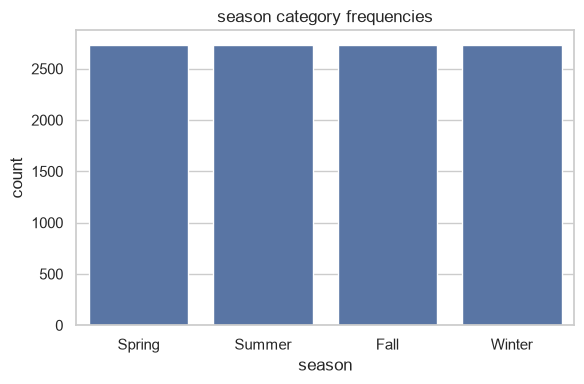

season
Spring    25.0
Summer    25.0
Fall      25.0
Winter    25.0
Name: proportion, dtype: float64


In [15]:
plot_categorical_distribution(df["season"], "season")

## holiday

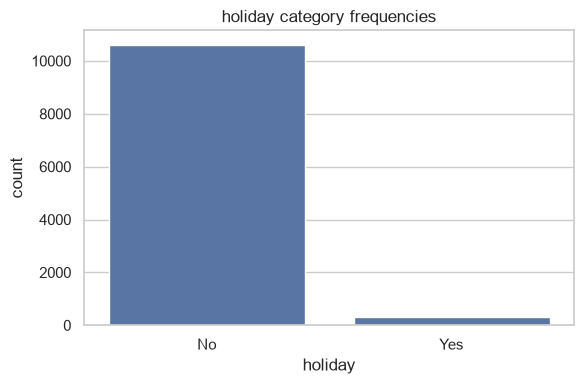

holiday
No     97.039474
Yes     2.960526
Name: proportion, dtype: float64


In [16]:
plot_categorical_distribution(df["holiday"], "holiday")

## workingday

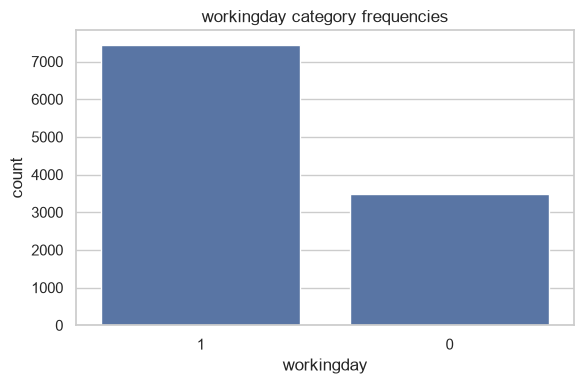

workingday
1    68.092105
0    31.907895
Name: proportion, dtype: float64


In [17]:
plot_categorical_distribution(df["workingday"], "workingday")

## weather

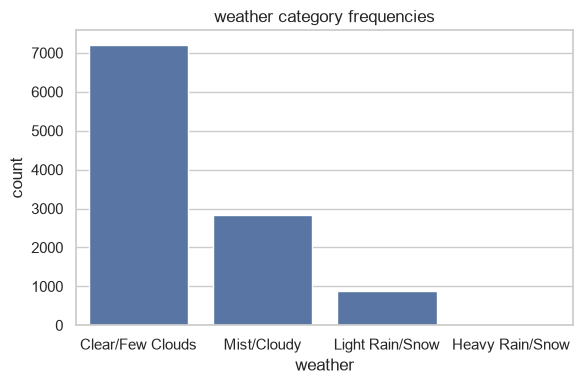

weather
Clear/Few Clouds    65.935673
Mist/Cloudy         26.005117
Light Rain/Snow      8.050073
Heavy Rain/Snow      0.009137
Name: proportion, dtype: float64


In [18]:
plot_categorical_distribution(df["weather"], "weather")

## temp

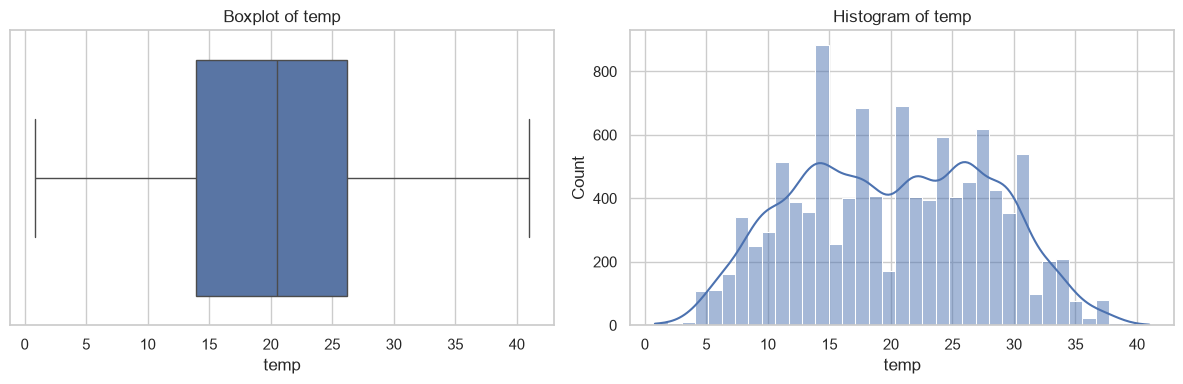

Skewness of temp: 0.0052
Kurtosis of temp: -0.9173


In [19]:
plot_numeric_distribution(df["temp"], "temp")

## atemp

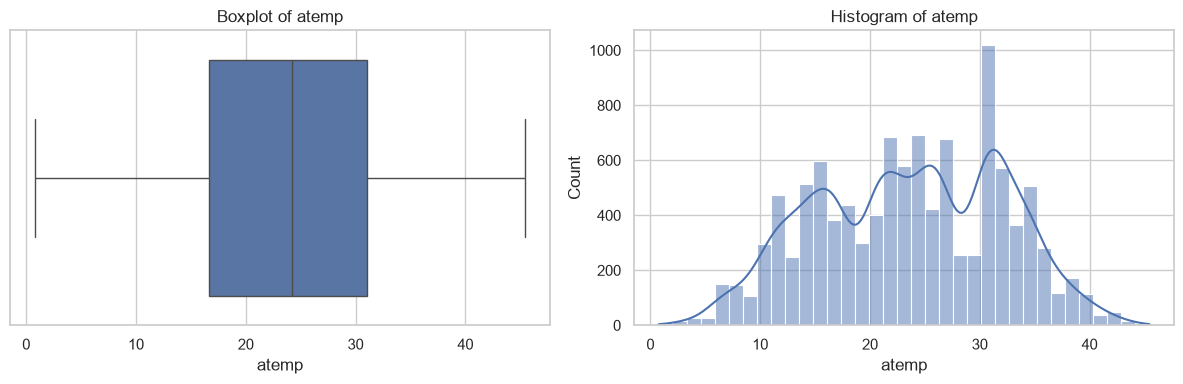

Skewness of atemp: -0.1014
Kurtosis of atemp: -0.8545


In [20]:
plot_numeric_distribution(df["atemp"], "atemp")

## humidity

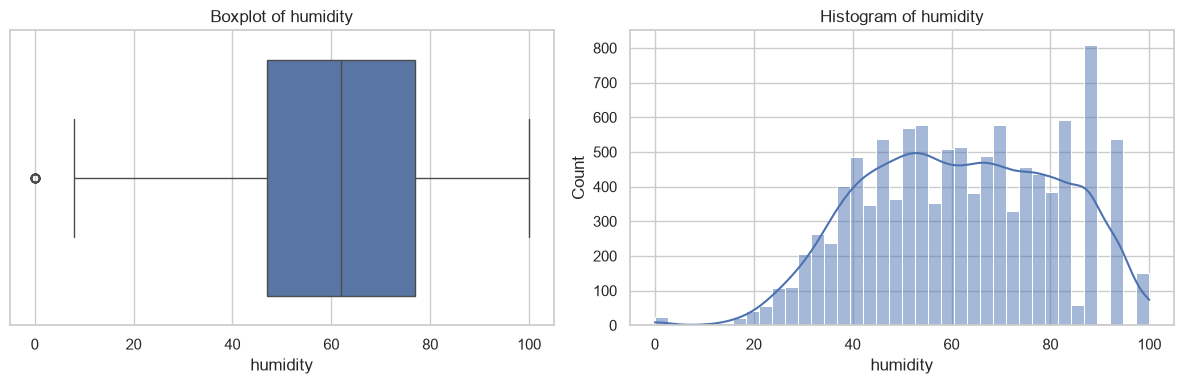

Skewness of humidity: -0.0917
Kurtosis of humidity: -0.7512


In [21]:
plot_numeric_distribution(df["humidity"], "humidity")

## windspeed

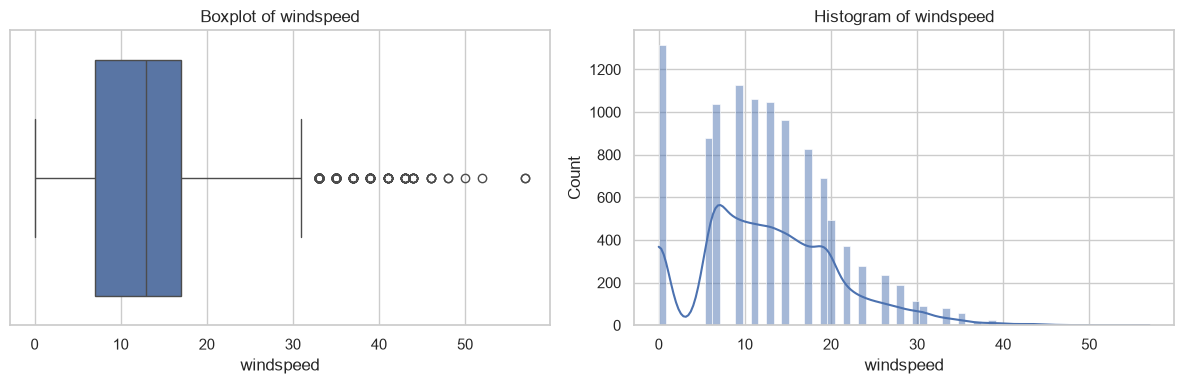

Skewness of windspeed: 0.5904
Kurtosis of windspeed: 0.6395


In [22]:
plot_numeric_distribution(df["windspeed"], "windspeed")

## count

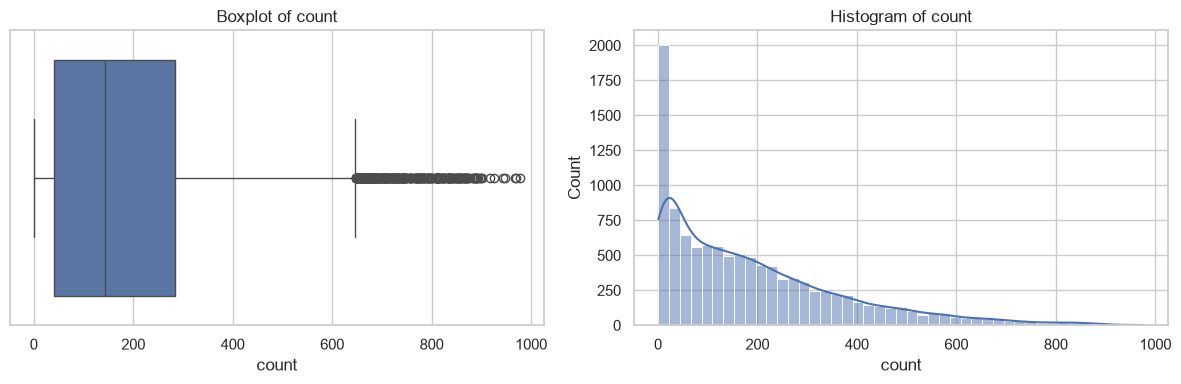

Skewness of count: 1.2453
Kurtosis of count: 1.3066


In [23]:
plot_numeric_distribution(df["count"], "count")

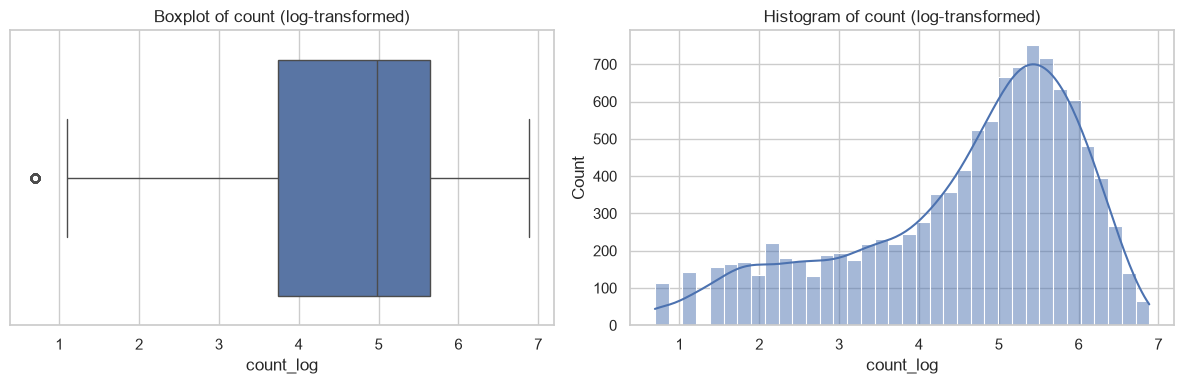

Skewness of count (log-transformed): -0.8462
Kurtosis of count (log-transformed): -0.1509


In [24]:
df_log = df.copy()
df_log['count_log'] = np.log1p(df_log['count'])

plot_numeric_distribution(df_log["count_log"], "count (log-transformed)")

## Datetime-derived features

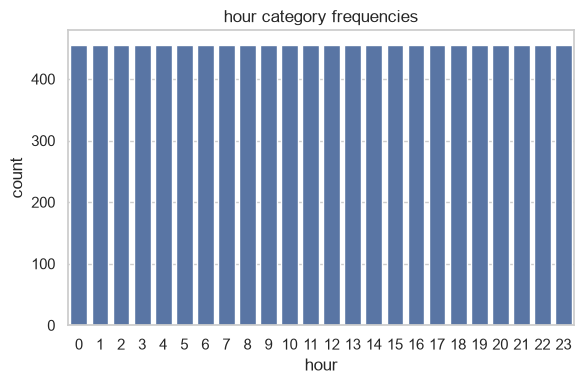

hour
0     4.166667
1     4.166667
2     4.166667
3     4.166667
4     4.166667
5     4.166667
6     4.166667
7     4.166667
8     4.166667
9     4.166667
10    4.166667
11    4.166667
12    4.166667
13    4.166667
14    4.166667
15    4.166667
16    4.166667
17    4.166667
18    4.166667
19    4.166667
20    4.166667
21    4.166667
22    4.166667
23    4.166667
Name: proportion, dtype: float64


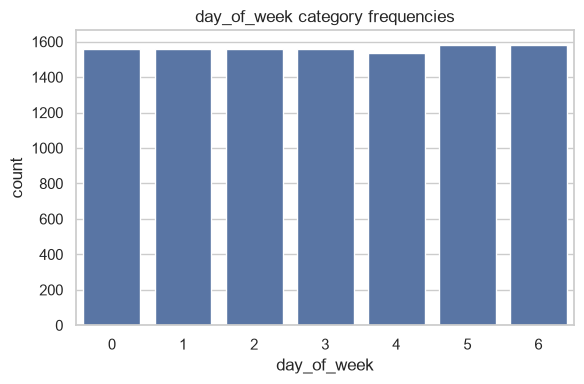

day_of_week
0    14.254386
1    14.254386
2    14.254386
3    14.254386
4    14.035088
5    14.473684
6    14.473684
Name: proportion, dtype: float64


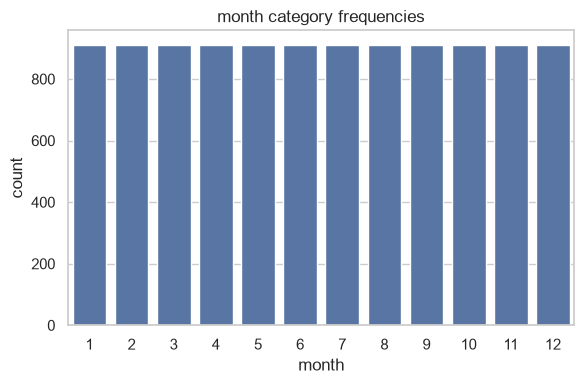

month
1     8.333333
2     8.333333
3     8.333333
4     8.333333
5     8.333333
6     8.333333
7     8.333333
8     8.333333
9     8.333333
10    8.333333
11    8.333333
12    8.333333
Name: proportion, dtype: float64


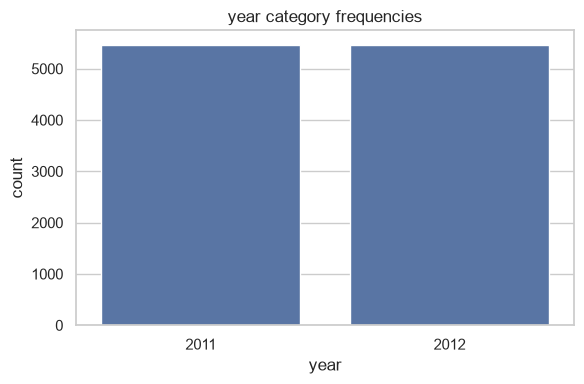

year
2011    50.0
2012    50.0
Name: proportion, dtype: float64


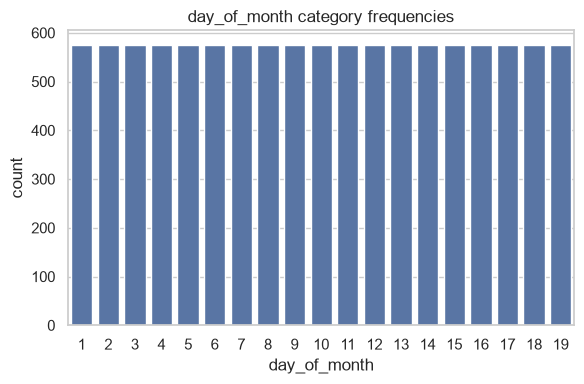

day_of_month
1     5.263158
2     5.263158
3     5.263158
4     5.263158
5     5.263158
6     5.263158
7     5.263158
8     5.263158
9     5.263158
10    5.263158
11    5.263158
12    5.263158
13    5.263158
14    5.263158
15    5.263158
16    5.263158
17    5.263158
18    5.263158
19    5.263158
Name: proportion, dtype: float64


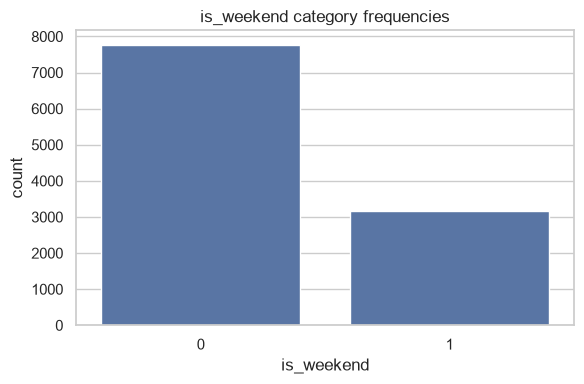

is_weekend
0    71.052632
1    28.947368
Name: proportion, dtype: float64


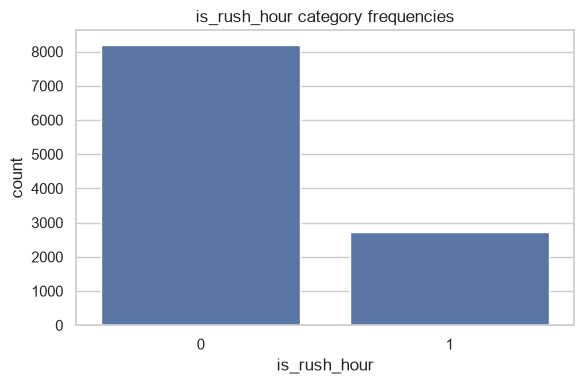

is_rush_hour
0    75.0
1    25.0
Name: proportion, dtype: float64


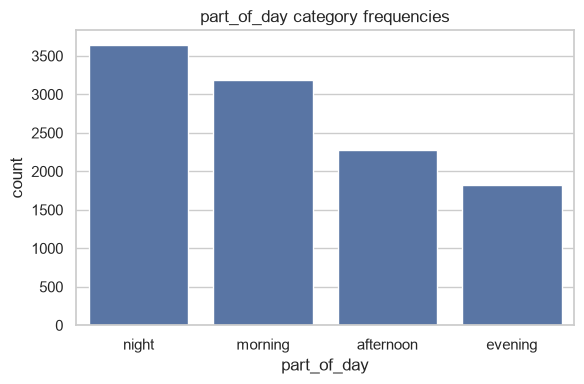

part_of_day
night        33.333333
morning      29.166667
afternoon    20.833333
evening      16.666667
Name: proportion, dtype: float64


In [25]:
for col in new_categorical_features:
    order = sorted(df[col].unique()) if col != "part_of_day" else None
    plot_categorical_distribution(df[col], col, order=order)

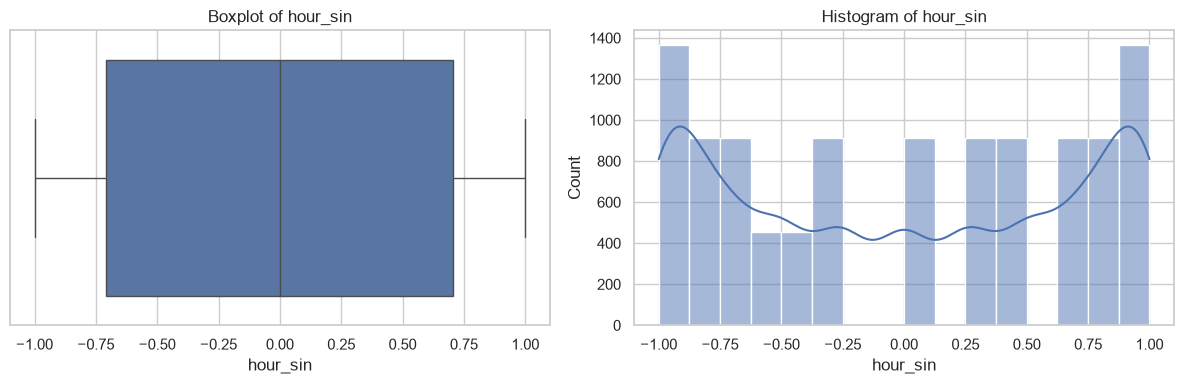

Skewness of hour_sin: 0.0000
Kurtosis of hour_sin: -1.5000


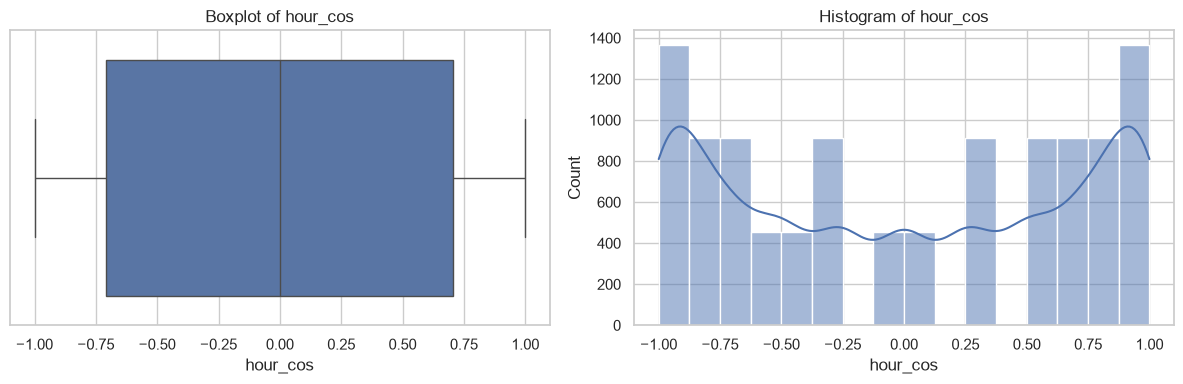

Skewness of hour_cos: 0.0000
Kurtosis of hour_cos: -1.5000


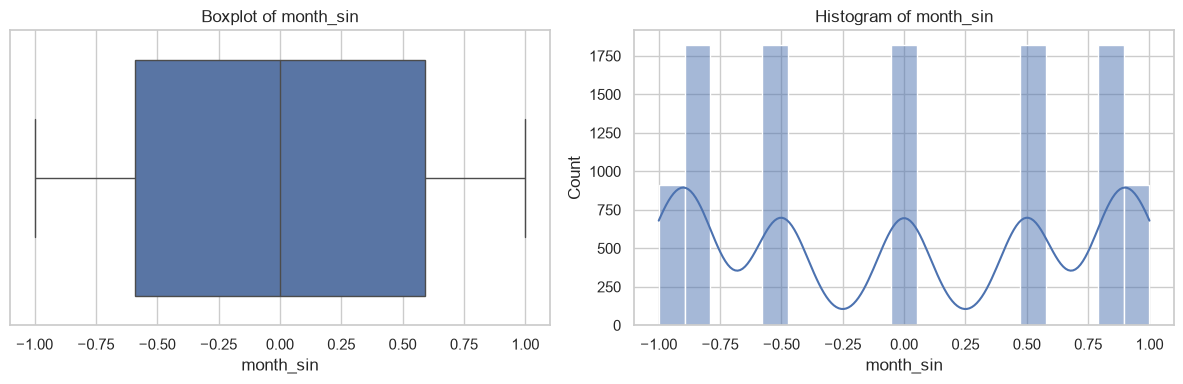

Skewness of month_sin: 0.0000
Kurtosis of month_sin: -1.5000


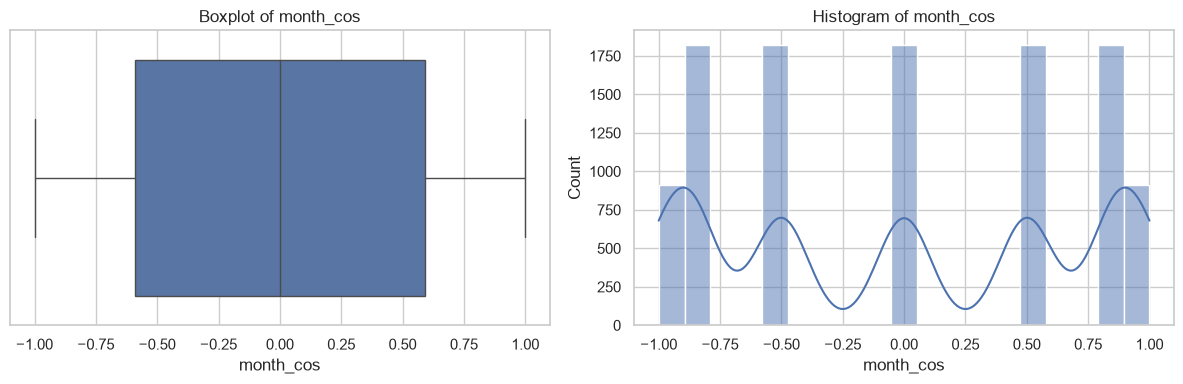

Skewness of month_cos: 0.0000
Kurtosis of month_cos: -1.5000


In [26]:
for col in cyclic_features:
    plot_numeric_distribution(df[col], col)

# 3. Predictor-Target Correlation Analysis

In [27]:
def numeric_vs_target(col, target="count"):
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df[target], alpha=0.3, ax=ax)
    ax.set_title(f"{col} vs {target}")
    plt.tight_layout()
    plt.show()

    pearson_r, pearson_p = stats.pearsonr(df[col], df[target])
    spearman_r, spearman_p = stats.spearmanr(df[col], df[target])
    print(
        f"Pearson correlation ({col} vs {target}): "
        f"r = {pearson_r:.4f}, p-value = {pearson_p:.4e}"
    )
    print(
        f"Spearman correlation ({col} vs {target}): "
        f"r = {spearman_r:.4f}, p-value = {spearman_p:.4e}"
    )


def categorical_vs_target(col, target="count"):
    summary = df.groupby(col)[target].agg(["sum", "mean"]).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=summary, x=col, y="sum", ax=axes[0])
    axes[0].set_title(f"Total {target} by {col}")
    sns.barplot(data=summary, x=col, y="mean", ax=axes[1])
    axes[1].set_title(f"Mean {target} by {col}")
    plt.tight_layout()
    plt.show()
    display(summary)

## temp vs count

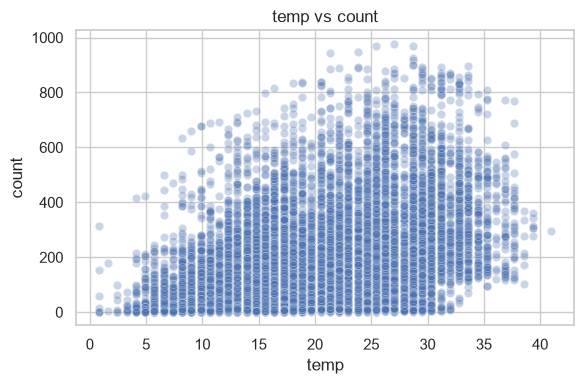

Pearson correlation (temp vs count): r = 0.3982, p-value = 0.0000e+00
Spearman correlation (temp vs count): r = 0.4139, p-value = 0.0000e+00


In [28]:
numeric_vs_target("temp")

## atemp vs count

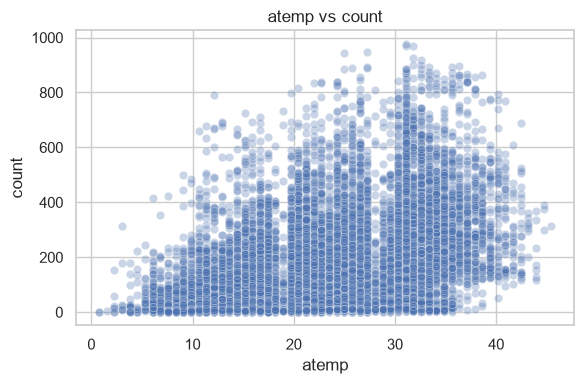

Pearson correlation (atemp vs count): r = 0.3937, p-value = 0.0000e+00
Spearman correlation (atemp vs count): r = 0.4125, p-value = 0.0000e+00


In [29]:
numeric_vs_target("atemp")

## humidity vs count

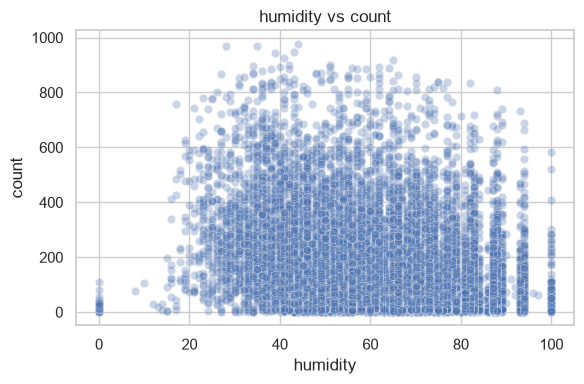

Pearson correlation (humidity vs count): r = -0.3176, p-value = 5.1916e-255
Spearman correlation (humidity vs count): r = -0.3544, p-value = 0.0000e+00


In [30]:
numeric_vs_target("humidity")

## windspeed vs count

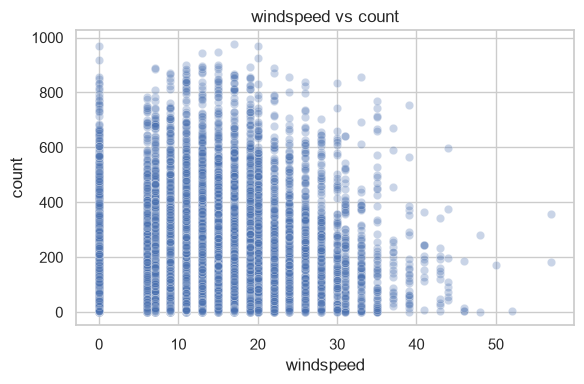

Pearson correlation (windspeed vs count): r = 0.0999, p-value = 1.0744e-25
Spearman correlation (windspeed vs count): r = 0.1332, p-value = 1.5945e-44


In [31]:
numeric_vs_target("windspeed")

## season vs count

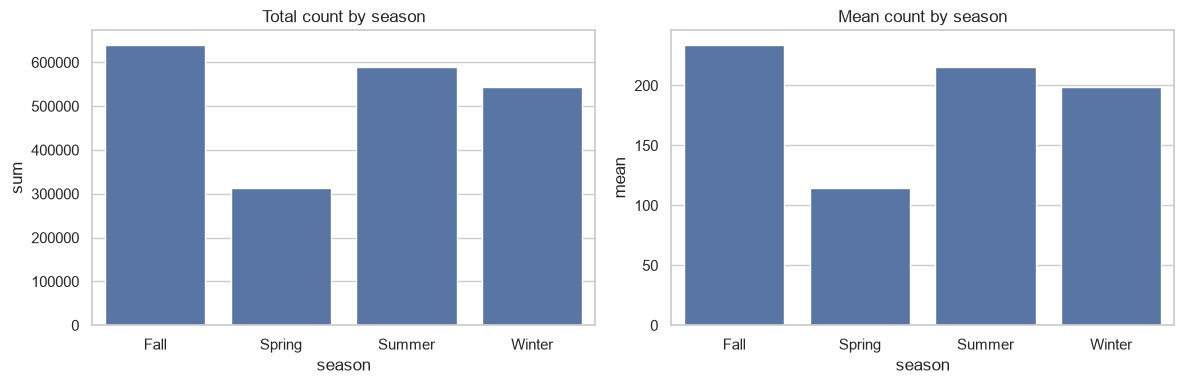

,season,sum,mean
0,Fall,640676,234.165205
1,Spring,312743,114.306652
2,Summer,588298,215.021199
3,Winter,544047,198.847588


In [32]:
categorical_vs_target("season")

## holiday vs count

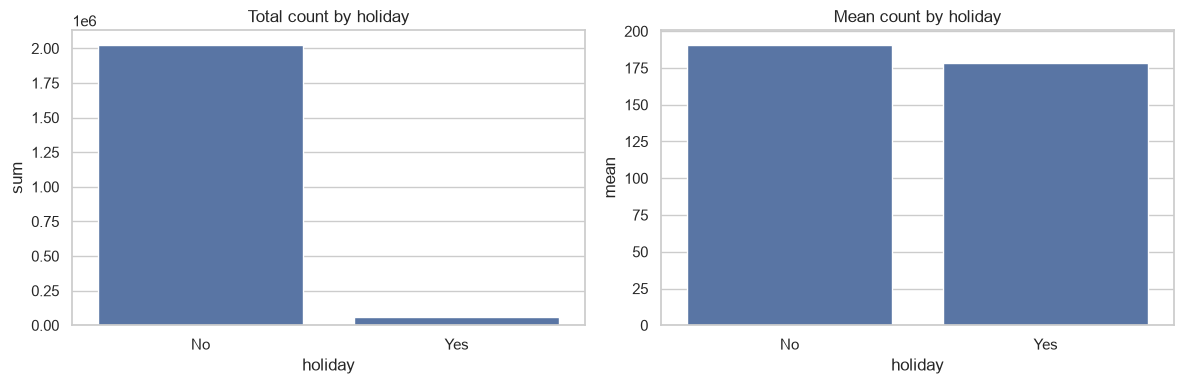

,holiday,sum,mean
0,No,2027901,190.951130
1,Yes,57863,178.589506


In [33]:
categorical_vs_target("holiday")

## workingday vs count

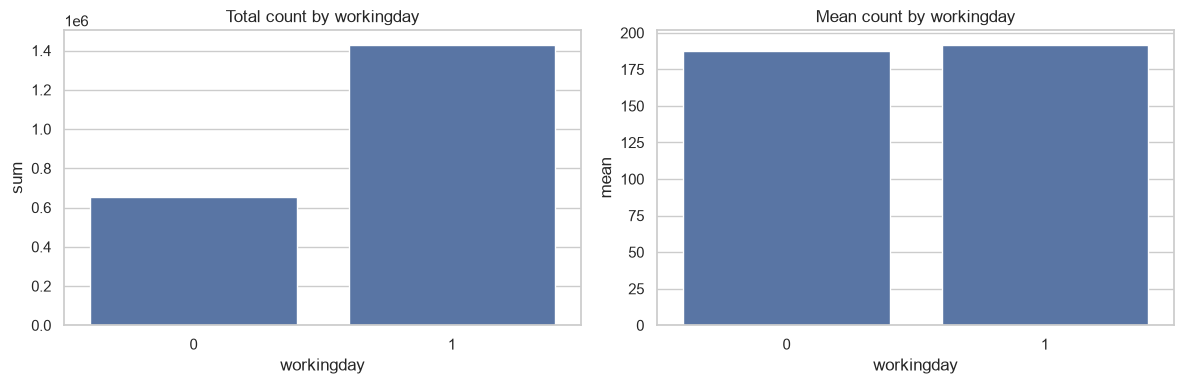

,workingday,sum,mean
0,0,655029,187.579897
1,1,1430735,191.993425


In [34]:
categorical_vs_target("workingday")

## weather vs count

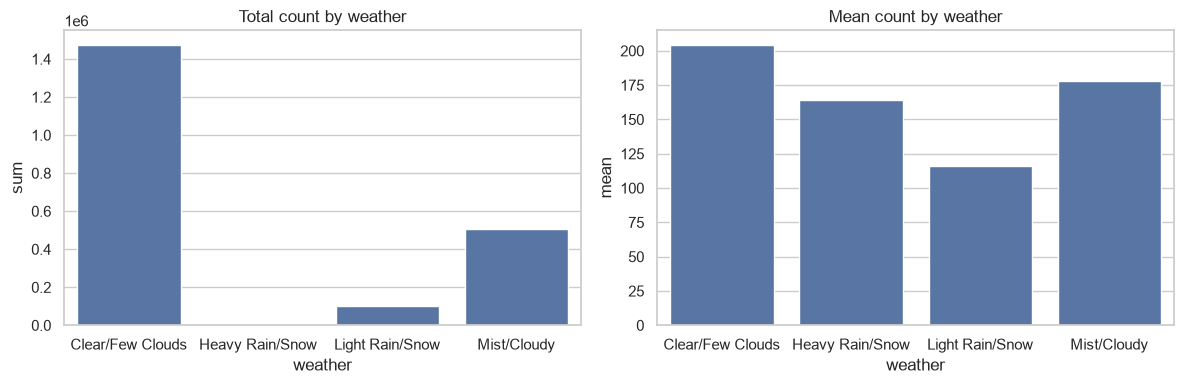

,weather,sum,mean
0,Clear/Few Clouds,1476224,204.576497
1,Heavy Rain/Snow,164,164.000000
2,Light Rain/Snow,102179,115.980704
3,Mist/Cloudy,507197,178.213985


In [35]:
categorical_vs_target("weather")

## Datetime-derived features vs count

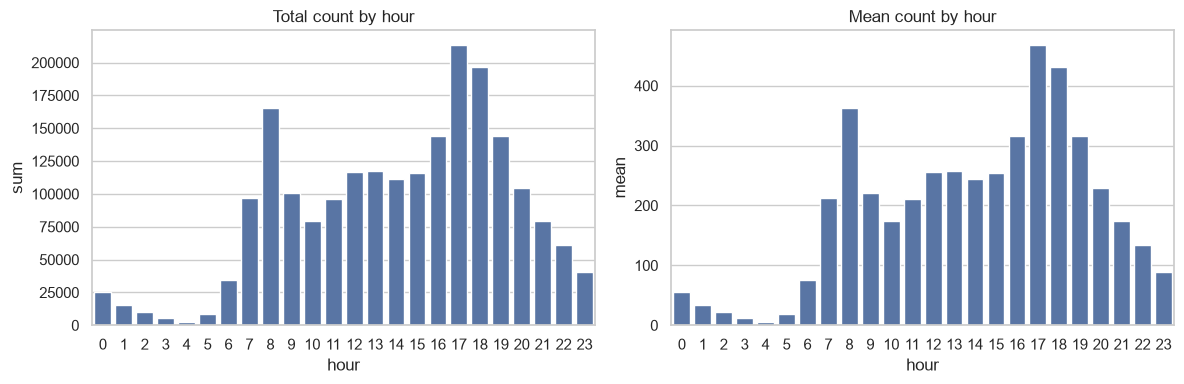

,hour,sum,mean
0,0,25092,55.026316
1,1,15384,33.736842
2,2,10377,22.756579
3,3,5178,11.355263
4,4,2863,6.278509
5,5,8947,19.620614
6,6,34702,76.100877
7,7,96972,212.657895
8,8,165064,361.982456
9,9,100914,221.302632


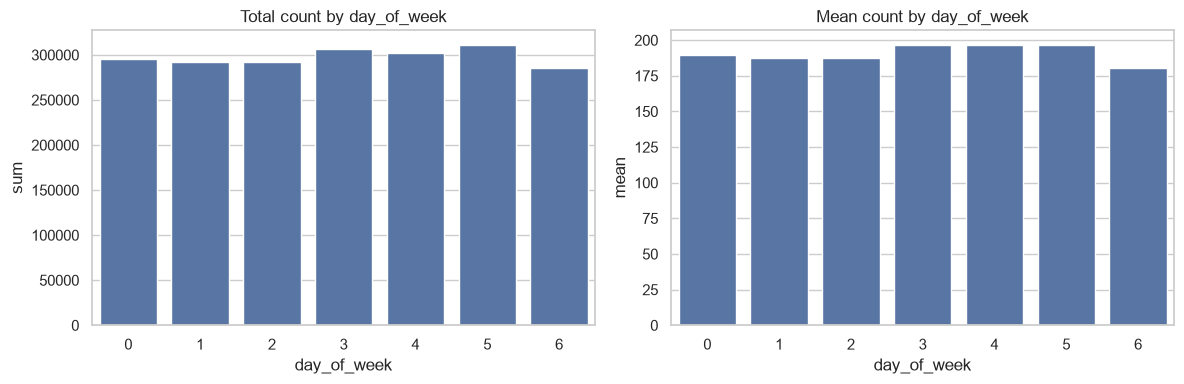

,day_of_week,sum,mean
0,0,295331,189.314744
1,1,292072,187.225641
2,2,292256,187.343590
3,3,306419,196.422436
4,4,302520,196.953125
5,5,311518,196.665404
6,6,285648,180.333333


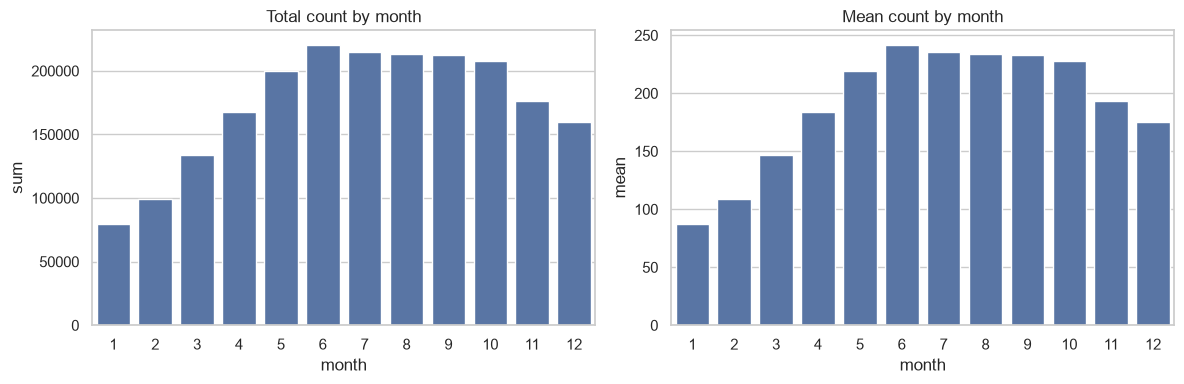

,month,sum,mean
0,1,79980,87.697368
1,2,99145,108.711623
2,3,133618,146.510965
3,4,167418,183.572368
4,5,200147,219.459430
5,6,220733,242.031798
6,7,214617,235.325658
7,8,213516,234.118421
8,9,212543,233.051535
9,10,207441,227.457237


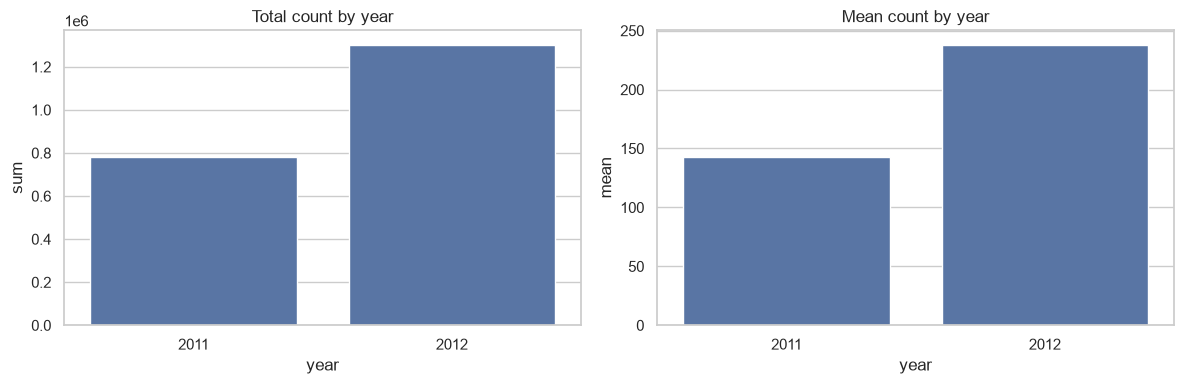

,year,sum,mean
0,2011,782167,142.939876
1,2012,1303597,238.230446


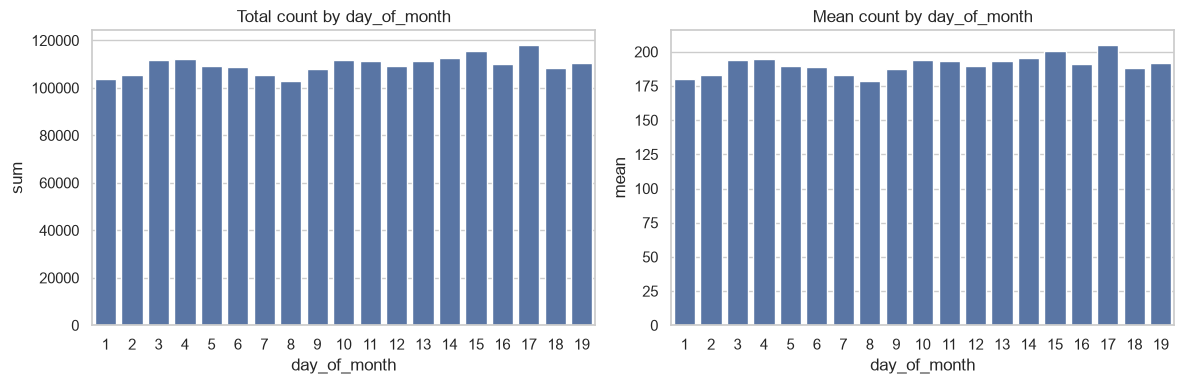

,day_of_month,sum,mean
0,1,103694,180.024306
1,2,105396,182.979167
2,3,111566,193.690972
3,4,112337,195.029514
4,5,109117,189.439236
5,6,108616,188.569444
6,7,105489,183.140625
7,8,102780,178.437500
8,9,108043,187.574653
9,10,111654,193.843750


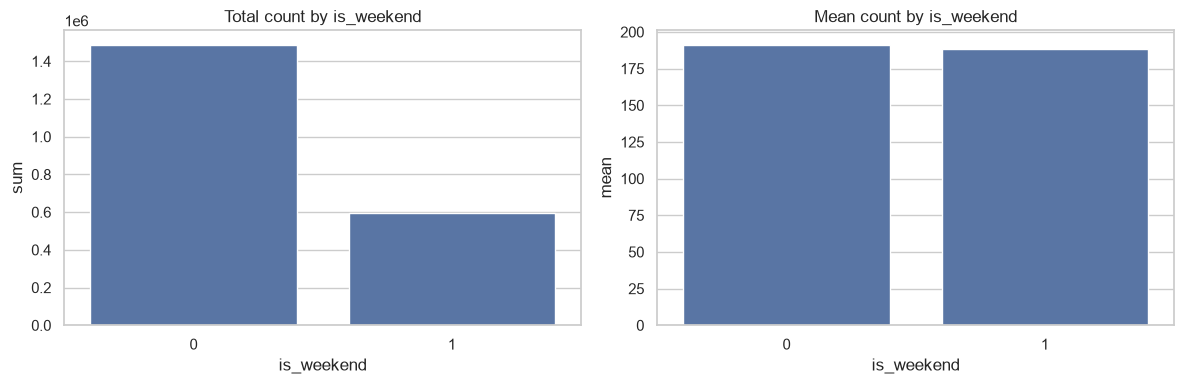

,is_weekend,sum,mean
0,0,1488598,191.434928
1,1,597166,188.499369


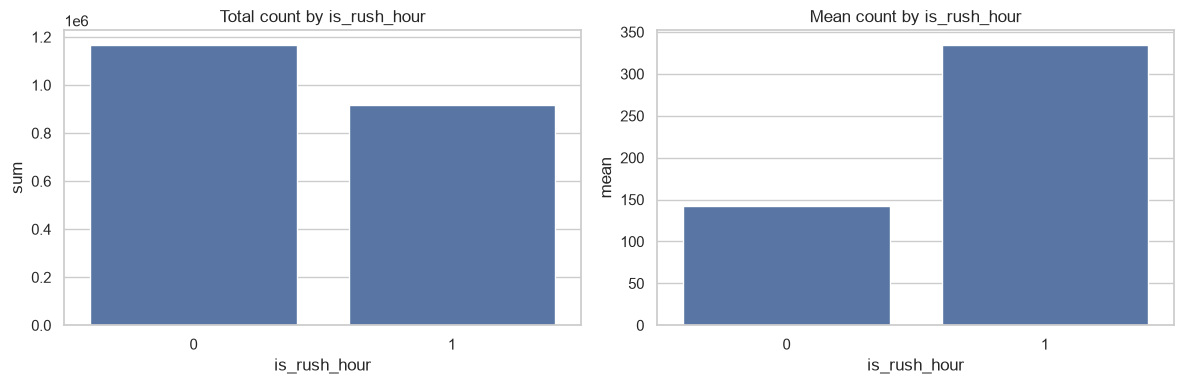

,is_rush_hour,sum,mean
0,0,1168818,142.399854
1,1,916946,335.141082


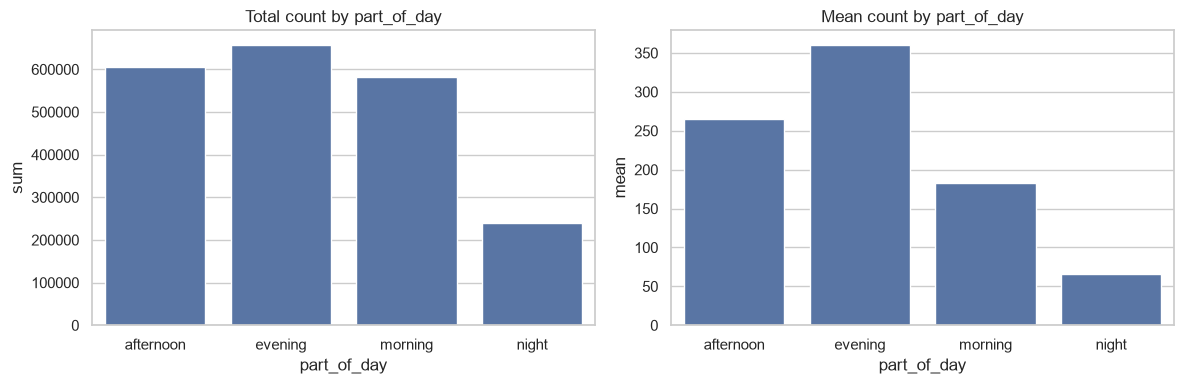

,part_of_day,sum,mean
0,afternoon,605755,265.682018
1,evening,658200,360.855263
2,morning,582131,182.371867
3,night,239678,65.701206


In [36]:
for col in new_categorical_features:
    categorical_vs_target(col)

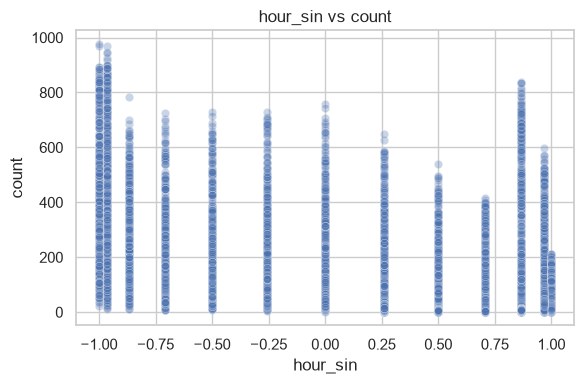

Pearson correlation (hour_sin vs count): r = -0.4212, p-value = 0.0000e+00
Spearman correlation (hour_sin vs count): r = -0.4706, p-value = 0.0000e+00


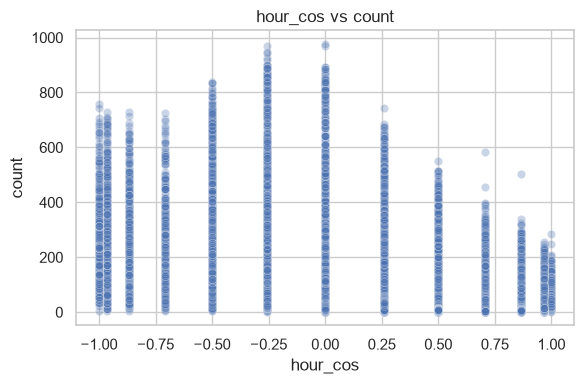

Pearson correlation (hour_cos vs count): r = -0.4158, p-value = 0.0000e+00
Spearman correlation (hour_cos vs count): r = -0.5162, p-value = 0.0000e+00


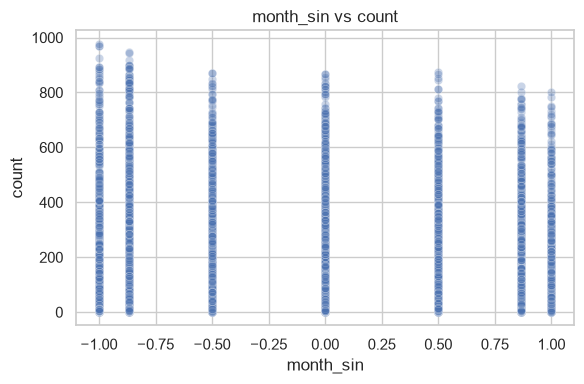

Pearson correlation (month_sin vs count): r = -0.1912, p-value = 1.1964e-90
Spearman correlation (month_sin vs count): r = -0.1773, p-value = 5.8879e-78


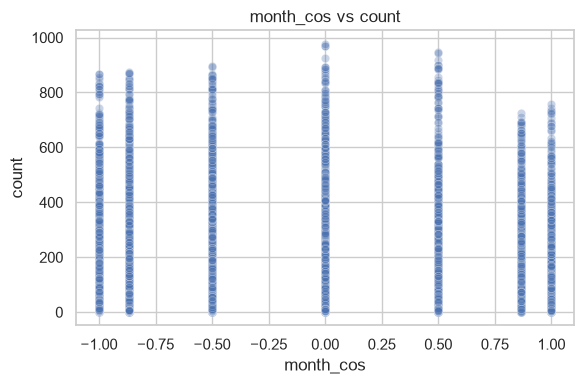

Pearson correlation (month_cos vs count): r = -0.1675, p-value = 1.0359e-69
Spearman correlation (month_cos vs count): r = -0.1780, p-value = 1.2840e-78


In [37]:
for col in cyclic_features:
    numeric_vs_target(col)

# 4. Predictor-Predictor Correlation Analysis (Multicollinearity)

## Correlation matrix of numerical predictors

In [38]:
numeric_predictors = [
    "temp", "atemp", "humidity", "windspeed",
    "hour", "day_of_week", "month", "year", "day_of_month",
    "is_weekend", "is_rush_hour",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]
corr_matrix = df[numeric_predictors].corr(method="pearson")
corr_matrix

,temp,atemp,humidity,windspeed,hour,day_of_week,month,year,day_of_month,is_weekend,is_rush_hour,hour_sin,hour_cos,month_sin,month_cos
temp,1.000000,0.985059,-0.066810,-0.018568,1.516544e-01,-3.454608e-02,2.647481e-01,6.611579e-02,1.304778e-02,-2.706417e-02,7.339912e-03,-2.016766e-01,-1.385937e-01,-5.158874e-01,-6.915123e-01
atemp,0.985059,1.000000,-0.045731,-0.058452,1.468836e-01,-3.589007e-02,2.715879e-01,6.374348e-02,8.990347e-03,-1.939326e-02,4.784261e-03,-1.951160e-01,-1.304311e-01,-5.013879e-01,-6.793166e-01
humidity,-0.066810,-0.045731,1.000000,-0.316662,-2.783052e-01,-2.824231e-02,2.001902e-01,-8.022872e-02,-9.015430e-03,9.536299e-03,-2.331882e-02,3.672572e-01,2.761162e-01,-1.783752e-01,3.101806e-02
windspeed,-0.018568,-0.058452,-0.316662,1.000000,1.448720e-01,-2.626244e-02,-1.504527e-01,-1.586007e-02,3.690469e-02,-1.718506e-02,4.906839e-02,-1.805010e-01,-1.799004e-01,1.537334e-01,1.441703e-02
hour,0.151654,0.146884,-0.278305,0.144872,1.000000e+00,-1.676412e-17,6.245079e-16,4.538647e-15,8.346333e-17,5.002271e-18,1.251086e-01,-7.759122e-01,-1.021508e-01,-4.134331e-16,3.203008e-16
day_of_week,-0.034546,-0.035890,-0.028242,-0.026262,-1.676412e-17,1.000000e+00,9.508300e-04,-2.188210e-03,-1.218508e-02,7.933262e-01,-1.129105e-17,5.586578e-18,7.443999e-19,7.418101e-03,-5.554550e-05
month,0.264748,0.271588,0.200190,-0.150453,6.245079e-16,9.508300e-04,1.000000e+00,5.469004e-13,-1.099506e-16,5.603032e-03,9.432915e-16,-4.155964e-19,3.690496e-18,-7.644607e-01,2.048366e-01
year,0.066116,0.063743,-0.080229,-0.015860,4.538647e-15,-2.188210e-03,5.469004e-13,1.000000e+00,-8.025510e-15,-2.861629e-14,2.350604e-15,-1.374261e-16,1.720531e-15,-3.901190e-13,7.291990e-13
day_of_month,0.013048,0.008990,-0.009015,0.036905,8.346333e-17,-1.218508e-02,-1.099506e-16,-8.025510e-15,1.000000e+00,-5.297014e-03,5.805194e-17,6.181595e-19,4.190912e-19,-1.406470e-16,2.157062e-16
is_weekend,-0.027064,-0.019393,0.009536,-0.017185,5.002271e-18,7.933262e-01,5.603032e-03,-2.861629e-14,-5.297014e-03,1.000000e+00,-6.341038e-18,5.915564e-18,2.941965e-18,1.586860e-03,5.922242e-03


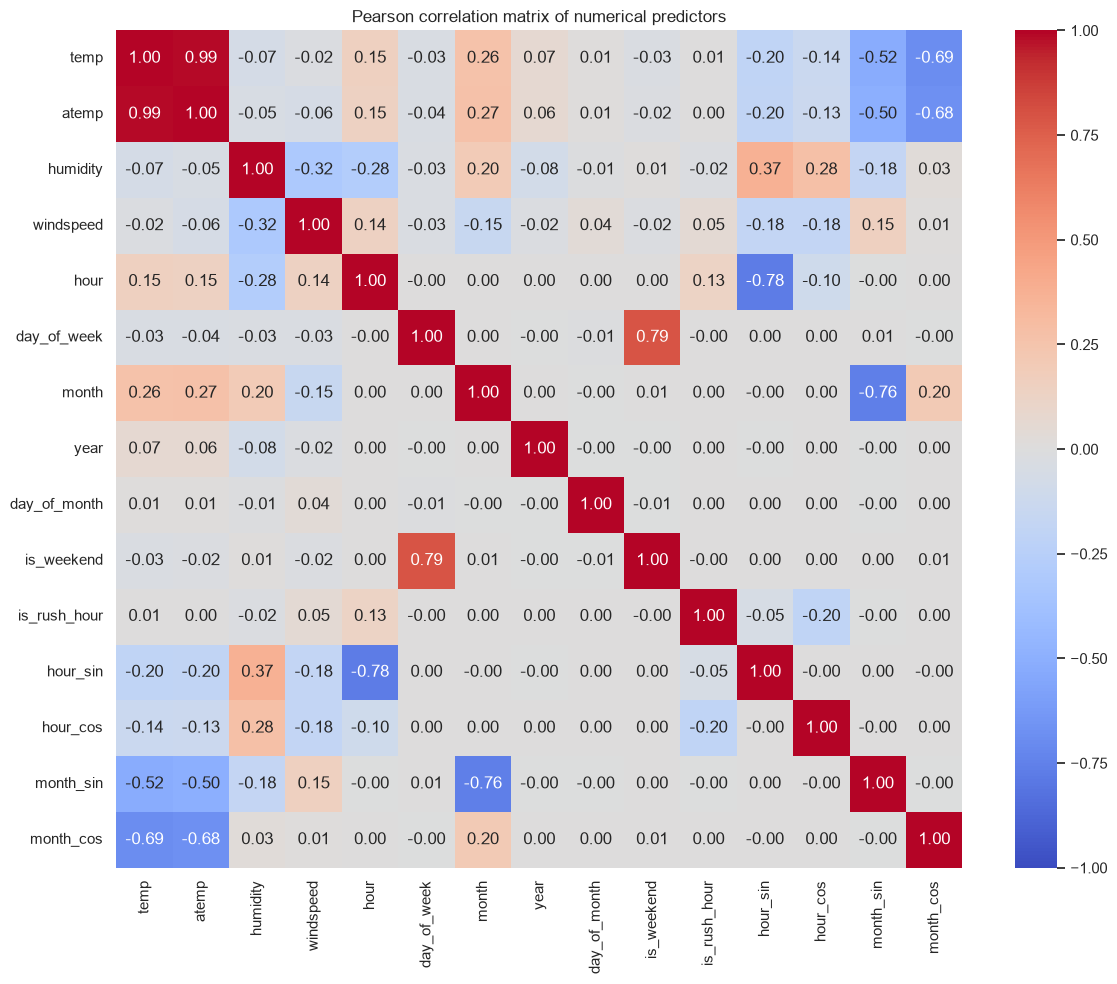

In [39]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson correlation matrix of numerical predictors")
plt.tight_layout()
plt.show()

## Multicollinearity flags

In [40]:
high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((cols[i], cols[j], r))

if high_corr_pairs:
    print("Predictor pairs with |r| > 0.7 (multicollinearity risk):")
    for a, b, r in high_corr_pairs:
        print(f"- {a} vs {b}: r = {r:.4f}")
else:
    print("No predictor pairs with |r| > 0.7 found.")

Predictor pairs with |r| > 0.7 (multicollinearity risk):
- temp vs atemp: r = 0.9851
- hour vs hour_sin: r = -0.7759
- day_of_week vs is_weekend: r = 0.7933
- month vs month_sin: r = -0.7645


As expected, `temp` and `atemp` are highly correlated, since both measure temperature (`atemp` being the "feels like" variant). This is a multicollinearity risk: including both in the same linear model can inflate coefficient variance and make individual coefficient estimates unstable, so only one of the two (or a derived combination) should typically be kept as a predictor.

# Conclusions

**Distributions**
1. the target variable is moderately left-skewed, so applying the log transformation may be useful.

**Correlations**

1. There is a positive, moderate, and significant correlation between **temp** and the target variable.
2. The same applies to **atemp**, which also shows a positive, moderate, and significant correlation with the target variable.
3. There is a negative, moderate, and significant correlation between **humidity** and the target variable.
4. There is a week correlation between **windspeed** and the target variable. However, by the domain context it may be useful to use it, because customer may rent less bikes during times with high windspeeds.
5. There is a significant relationship between **season** and the target variable: the quantity is lower during spring.
6. On holidays, the quantity is significantly higher.
7. It was not possible to see a significant difference between workdays and non-workdays. However, it's going to be used since by the domain context it may be useful.
8. Regarding **weather**, the quantity is lower on days with light rain/snow and slightly lower on cloudy/foggy days.
9. The count is greater during the first hours of the morning and the last hours of the afternoon/first hours of night.
10. The count is greater in some months of the year (like May) and smaller in the first months of the year.
11. It was possible to see some difference by the day of the month. However, it is better no to use it since the test set only has rows with days from 20-31, not seen in the train set.

**Multicollinearity**

1. There is a very strong correlation between temp and atemp.
2. There is a moderate correlation between humidity and windspeed.

**Decisions**
1. keep temp, humidity, season, holidays, weather, windspeed and season features.
2. use hour and month as features because it's possible to see different count segments for different values of those features.
3. for linear models, drop atemp because it may lead to collinearity problems.
4. do not use day of month, since some values are seen only in the train set and not in the test set

**Note**: there may be a high correlation between month and season. Those features may be also used carefully in linear models.
